In [ ]:
#IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns",None)

In [ ]:
#LOAD DATASET
df = pd.read_csv("../data/raw/coffee_sales.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully
Shape: (149116, 11)


,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2025,7:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2025,7:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2025,7:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2025,7:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2025,7:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [ ]:
#DATASET COLUMNS
df.columns.tolist()

['transaction_id',
 'year',
 'transaction_time',
 'transaction_qty',
 'store_id',
 'store_location',
 'product_id',
 'unit_price',
 'product_category',
 'product_type',
 'product_detail']

In [26]:
#DATASET INFO
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    149116 non-null  int64  
 1   year              149116 non-null  int64  
 2   transaction_time  149116 non-null  str    
 3   transaction_qty   149116 non-null  int64  
 4   store_id          149116 non-null  int64  
 5   store_location    149116 non-null  str    
 6   product_id        149116 non-null  int64  
 7   unit_price        149116 non-null  float64
 8   product_category  149116 non-null  str    
 9   product_type      149116 non-null  str    
 10  product_detail    149116 non-null  str    
 11  revenue           149116 non-null  float64
 12  hour              149116 non-null  int32  
 13  time_bucket       149116 non-null  str    
dtypes: float64(2), int32(1), int64(5), str(6)
memory usage: 24.9 MB


In [ ]:
#MISSING VALUES
df.isnull().sum()

transaction_id      0
year                0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64

In [ ]:
#DUPLICATE RECORDS
df.duplicated().sum()

np.int64(0)

In [ ]:
#SAMPLE RECORDS
df.sample(5)

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
101352,101606,2025,8:58:34,2,8,Hell's Kitchen,32,3.00,Coffee,Gourmet brewed coffee,Ethiopia Rg
13463,13493,2025,13:00:14,1,5,Lower Manhattan,39,4.25,Coffee,Barista Espresso,Latte Rg
45291,45398,2025,15:49:19,1,3,Astoria,74,3.50,Bakery,Biscotti,Ginger Biscotti
92068,92322,2025,7:07:59,2,5,Lower Manhattan,26,3.00,Coffee,Organic brewed coffee,Brazilian Rg
13080,13110,2025,18:53:01,1,8,Hell's Kitchen,78,4.50,Bakery,Scone,Scottish Cream Scone


In [ ]:
#BASIC NUMERICAL SUMMARY
df.describe()

,transaction_id,year,transaction_qty,store_id,product_id,unit_price
count,149116.000000,149116.0,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,2025.0,1.438276,5.342063,47.918607,3.382219
std,43153.600016,0.0,0.542509,2.074241,17.930020,2.658723
min,1.000000,2025.0,1.000000,3.000000,1.000000,0.800000
25%,37335.750000,2025.0,1.000000,3.000000,33.000000,2.500000
50%,74727.500000,2025.0,1.000000,5.000000,47.000000,3.000000
75%,112094.250000,2025.0,2.000000,8.000000,60.000000,3.750000
max,149456.000000,2025.0,8.000000,8.000000,87.000000,45.000000


In [ ]:
#VALIDATION CHECKS
print("Minimum Quantity:", df["transaction_qty"].min())
print("Maximum Quantity:", df["transaction_qty"].max())

print("Minimum Unit Price:", df["unit_price"].min())
print("Maximum Unit Price:", df["unit_price"].max())

print("Negative or zero quantities:", (df["transaction_qty"] <= 0).sum())
print("Negative or zero prices:", (df["unit_price"] <= 0).sum())

Minimum Quantity: 1
Maximum Quantity: 8
Minimum Unit Price: 0.8
Maximum Unit Price: 45.0
Negative or zero quantities: 0
Negative or zero prices: 0


In [ ]:
#CREATE REVENUE FEATURE
df["revenue"] = df["transaction_qty"] * df["unit_price"]

df[["transaction_qty", "unit_price", "revenue"]].head()

,transaction_qty,unit_price,revenue
0,2,3.0,6.0
1,2,3.1,6.2
2,2,4.5,9.0
3,1,2.0,2.0
4,2,3.1,6.2


In [ ]:
#EXACT HOURS
df["hour"] = pd.to_datetime(
    df["transaction_time"],
    format ="%H:%M:%S"
).dt.hour

df[["transaction_time", "hour"]].head()

,transaction_time,hour
0,7:06:11,7
1,7:08:56,7
2,7:14:04,7
3,7:20:24,7
4,7:22:41,7


In [ ]:
#CREATE TIME BUCKETS
def get_time_bucket(hour):
    if 6 <= hour <= 11:
        return "Morning"
    elif 12 <= hour <= 16:
        return "Afternoon"
    else:
        return "Late Hours"
    
df["time_bucket"] = df["hour"].apply(get_time_bucket)

df[["transaction_time", "hour", "time_bucket"]].head()

,transaction_time,hour,time_bucket
0,7:06:11,7,Morning
1,7:08:56,7,Morning
2,7:14:04,7,Morning
3,7:20:24,7,Morning
4,7:22:41,7,Morning


In [ ]:
#DATASET AFTER FEAATURE ENGINEERING
df.head()

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,revenue,hour,time_bucket
0,1,2025,7:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0,7,Morning
1,2,2025,7:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,7,Morning
2,3,2025,7:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0,7,Morning
3,4,2025,7:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,7,Morning
4,5,2025,7:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,7,Morning


In [27]:
#KEY KPIs
total_revenue = df["revenue"].sum()
total_transactions = df["transaction_id"].nunique()
total_quantity = df["transaction_qty"].sum()
average_order_value = df["revenue"].mean()
total_stores = df["store_location"].nunique()

print("Total Revenue:", round(total_revenue, 2))
print("Total Transactions:", total_transactions)
print("Total Quantity Sold:", total_quantity)
print("Average Order Value:", round(average_order_value, 2))
print("Total Stores:", total_stores)

Total Revenue: 698812.33
Total Transactions: 149116
Total Quantity Sold: 214470
Average Order Value: 4.69
Total Stores: 3


In [29]:
#STORE LOCATIONS
df["store_location"].value_counts()

store_location
Hell's Kitchen     50735
Astoria            50599
Lower Manhattan    47782
Name: count, dtype: int64

In [30]:
#PRODUCT CATEGORIES
df["product_category"].value_counts()

product_category
Coffee                58416
Tea                   45449
Bakery                22796
Drinking Chocolate    11468
Flavours               6790
Coffee beans           1753
Loose Tea              1210
Branded                 747
Packaged Chocolate      487
Name: count, dtype: int64

In [31]:
#HOURLY REVENUE
hourly_revenue = (
    df.groupby("hour")["revenue"]
    .sum()
    .reset_index()
)

hourly_revenue

,hour,revenue
0,6,21900.27
1,7,63526.47
2,8,82699.87
3,9,85169.53
4,10,88673.39
5,11,46319.14
6,12,40192.79
7,13,40367.45
8,14,41304.74
9,15,41733.10


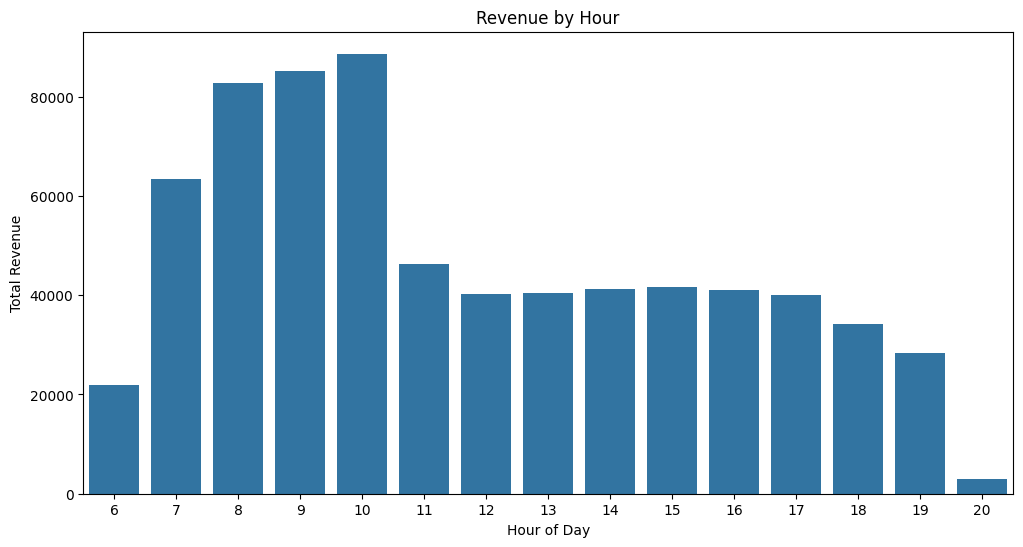

In [32]:
#REVENUE BY HOUR CHART
plt.figure(figsize=(12, 6))

sns.barplot(
    data=hourly_revenue,
    x="hour",
    y="revenue"
)

plt.title("Revenue by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)

plt.show()

In [33]:
#TOP REVENUE HOURS
hourly_revenue.sort_values(
    by="revenue",
    ascending=False
).head(10)

,hour,revenue
4,10,88673.39
3,9,85169.53
2,8,82699.87
1,7,63526.47
5,11,46319.14
9,15,41733.10
8,14,41304.74
10,16,41122.75
7,13,40367.45
6,12,40192.79


In [34]:
#HOURLY TRANSACTIONS
hourly_transactions = (
    df.groupby("hour")["transaction_id"]
    .count()
    .reset_index(name="transactions")
)

hourly_transactions

,hour,transactions
0,6,4594
1,7,13428
2,8,17654
3,9,17764
4,10,18545
5,11,9766
6,12,8708
7,13,8714
8,14,8933
9,15,8979


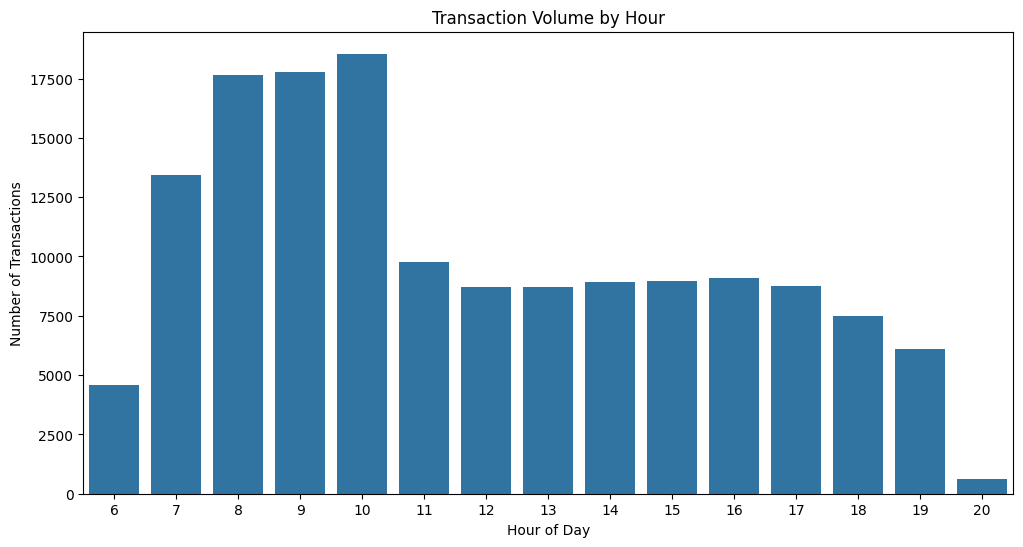

In [35]:
#TRANSACTIONS BY HOUR CHART
plt.figure(figsize=(12, 6))

sns.barplot(
    data=hourly_transactions,
    x="hour",
    y="transactions"
)

plt.title("Transaction Volume by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")

plt.show()

In [36]:
#TIME BUCKET REVENUE
bucket_revenue = (
    df.groupby("time_bucket")["revenue"]
    .sum()
    .reset_index()
    .sort_values(by="revenue", ascending=False)
)

bucket_revenue

,time_bucket,revenue
2,Morning,388288.67
0,Afternoon,204720.83
1,Late Hours,105802.83


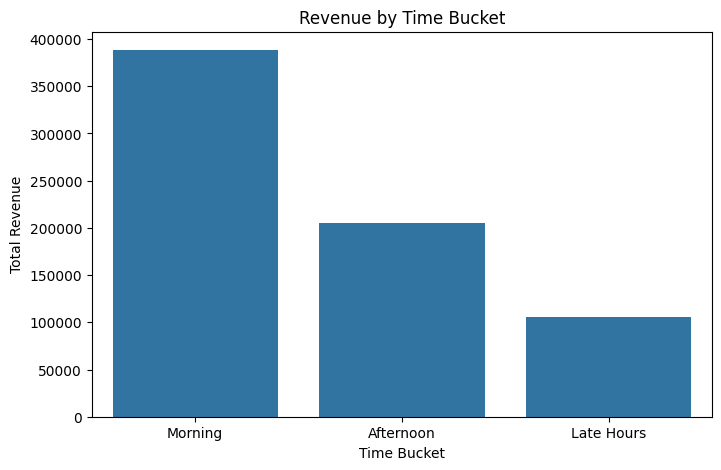

In [37]:
#TIME BUCKET REVENUE CHART
plt.figure(figsize=(8, 5))

sns.barplot(
    data=bucket_revenue,
    x="time_bucket",
    y="revenue"
)

plt.title("Revenue by Time Bucket")
plt.xlabel("Time Bucket")
plt.ylabel("Total Revenue")

plt.show()

In [38]:
#REVENUE BY STORE
store_revenue = (
    df.groupby("store_location")["revenue"]
    .sum()
    .reset_index()
    .sort_values(by="revenue", ascending=False)
)

store_revenue

,store_location,revenue
1,Hell's Kitchen,236511.17
0,Astoria,232243.91
2,Lower Manhattan,230057.25


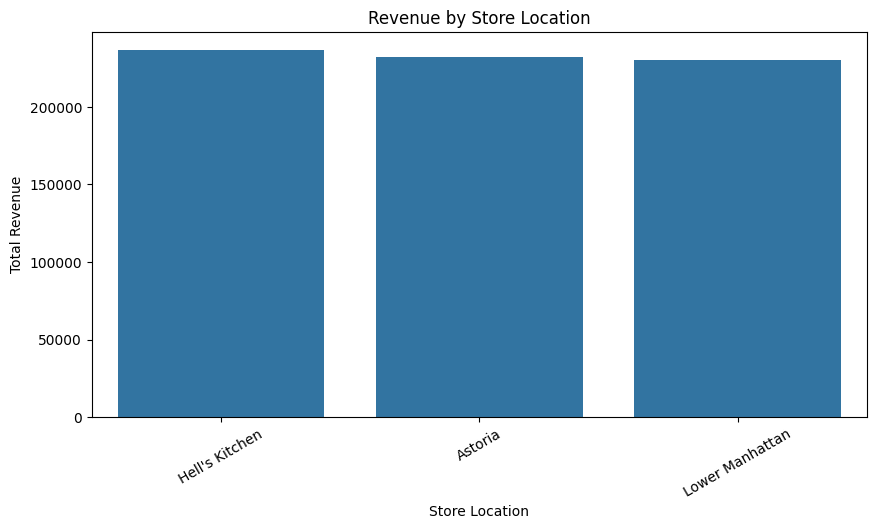

In [39]:
#STORE REVENUE CHART
plt.figure(figsize=(10, 5))

sns.barplot(
    data=store_revenue,
    x="store_location",
    y="revenue"
)

plt.title("Revenue by Store Location")
plt.xlabel("Store Location")
plt.ylabel("Total Revenue")
plt.xticks(rotation=30)

plt.show()

In [40]:
#STORE-WISE HOURLY HEATMAP
store_hour_heatmap = df.pivot_table(
    values="revenue",
    index="store_location",
    columns="hour",
    aggfunc="sum"
)

store_hour_heatmap

hour,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
store_location,,,,,,,,,,,,,,,
Astoria,NaN,19028.80,22805.90,23183.57,24426.12,15498.13,15681.20,15947.87,15175.27,15651.95,16110.85,15839.30,15951.30,16943.65,NaN
Hell's Kitchen,7531.17,15961.05,31544.44,32874.29,33605.81,17926.54,11343.10,12070.10,12297.50,11311.25,11990.48,12789.50,11863.21,10766.36,2636.37
Lower Manhattan,14369.10,28536.62,28349.53,29111.67,30641.46,12894.47,13168.49,12349.48,13831.97,14769.90,13021.42,11505.51,6471.69,736.67,299.27


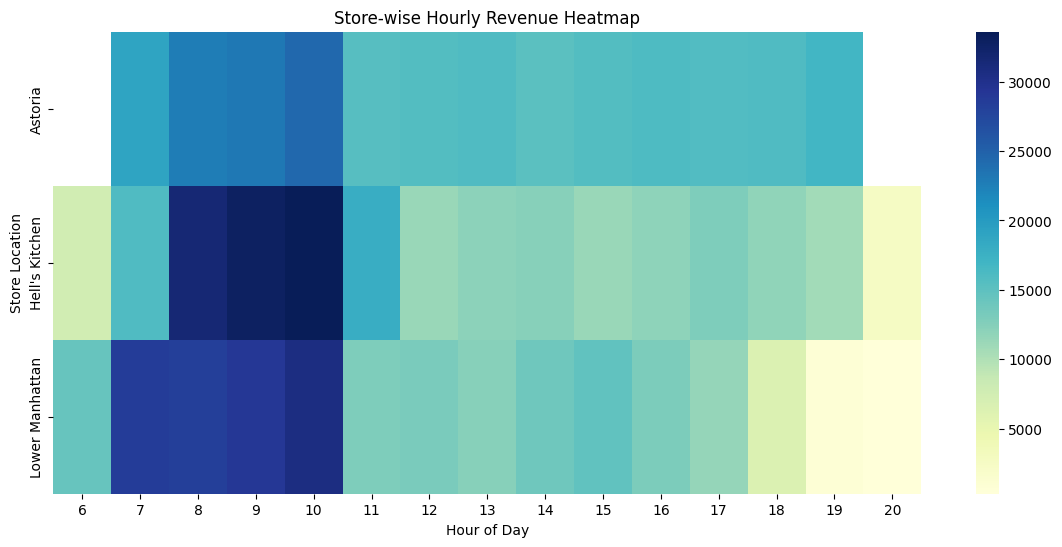

In [41]:
#HEATMAP CHART
plt.figure(figsize=(14, 6))

sns.heatmap(
    store_hour_heatmap,
    cmap="YlGnBu",
    annot=False
)

plt.title("Store-wise Hourly Revenue Heatmap")
plt.xlabel("Hour of Day")
plt.ylabel("Store Location")

plt.show()

In [42]:
#PRODUCT CATEGORY REVENUE
category_revenue = (
    df.groupby("product_category")["revenue"]
    .sum()
    .reset_index()
    .sort_values(by="revenue", ascending=False)
)

category_revenue

,product_category,revenue
2,Coffee,269952.45
8,Tea,196405.95
0,Bakery,82315.64
4,Drinking Chocolate,72416.00
3,Coffee beans,40085.25
1,Branded,13607.00
6,Loose Tea,11213.60
5,Flavours,8408.80
7,Packaged Chocolate,4407.64


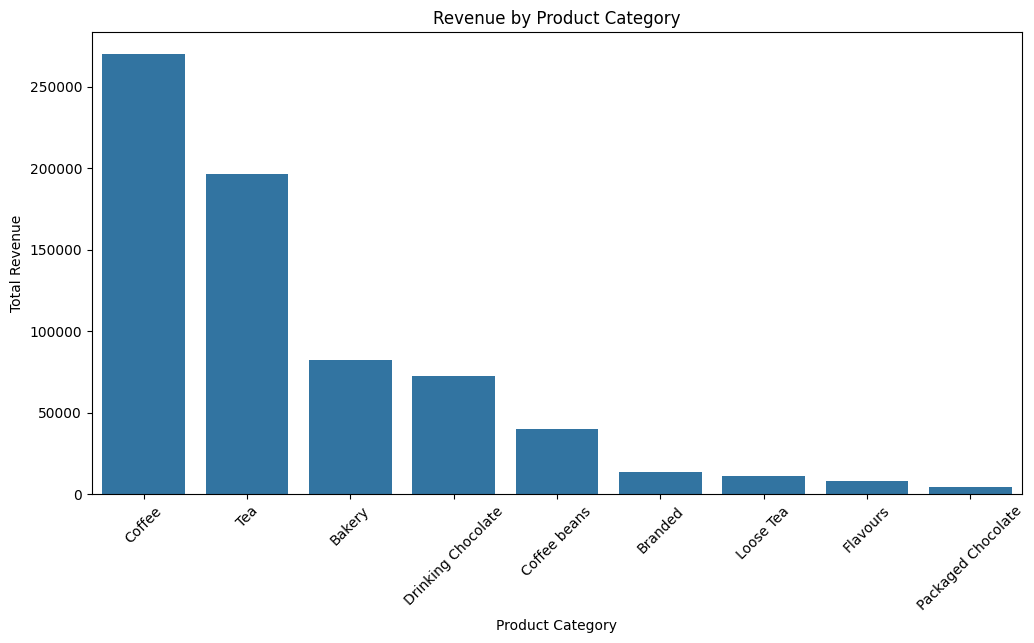

In [43]:
#PRODUCT CATEGORY REVENUE CHART 
plt.figure(figsize=(12, 6))

sns.barplot(
    data=category_revenue,
    x="product_category",
    y="revenue"
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.show()

In [44]:
#PRODUCT CATEGORY BY TIME BUCKET
category_bucket = df.pivot_table(
    values="revenue",
    index="product_category",
    columns="time_bucket",
    aggfunc="sum"
)

category_bucket

time_bucket,Afternoon,Late Hours,Morning
product_category,,,
Bakery,22743.10,11409.84,48162.70
Branded,3369.00,1668.00,8570.00
Coffee,83107.80,42372.85,144471.80
Coffee beans,7880.70,4026.00,28178.55
Drinking Chocolate,22320.00,11940.50,38155.50
Flavours,1736.00,896.00,5776.80
Loose Tea,2424.95,1402.75,7385.90
Packaged Chocolate,928.18,502.49,2976.97
Tea,60211.10,31584.40,104610.45


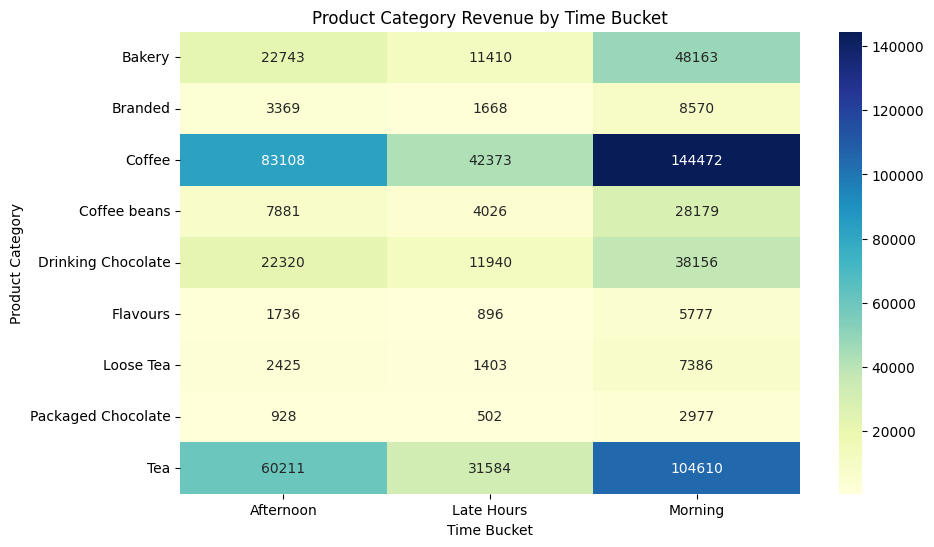

In [45]:
#CATEGORY_TIME HEATMAP
plt.figure(figsize=(10, 6))

sns.heatmap(
    category_bucket,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f"
)

plt.title("Product Category Revenue by Time Bucket")
plt.xlabel("Time Bucket")
plt.ylabel("Product Category")

plt.show()

In [46]:
df.to_csv(
    "../data/processed/coffee_sales_processed.csv",
    index=False
)

print("Processed dataset saved successfully")

Processed dataset saved successfully


## Dataset Limitation

The provided dataset does not contain a transaction date column. It includes only the transaction year and transaction time.

Because of this, day-of-week, daily trend, weekly trend, and weekday vs weekend analyses cannot be performed accurately.

Therefore, this analysis focuses on intraday demand patterns such as hourly revenue, transaction volume, time bucket performance, store-wise hourly demand, and product category performance.